# Exploring Other Neural Net Approaches

This notebook demonstrates how to make use of the gridded nature of the source data in ENSO prediction using a gridded MLP, and provides a gateway to more complex neural network architecture such as CNNs, ResNets or others of your own devising. The simple MLP example provided has skill, but is less accurate than the simple time-series models from previous steps. It is interesting to consider how this might challenge preconceptions around model complexity and the effectiveness of black-box approaches to modelling, while simultaneously inviting users to experiment with alternative ML architectures and starting to work with larger ML models.

In [1]:
# Necessary import
import pyearthtools.data
import pyearthtools.pipeline as petpipe
import site_archive_nci
import warnings
import xarray as xr
import numpy as np # np.cos and np.sin
import plotly.express as px
import matplotlib.pyplot as plt

import pandas as pd

import numpy as np
import scipy.stats

import scores 
import torch

# Total time frame for training the model
start = '1970-01'
end = '2024-12'

# Start by considering a specific date for visualising the process on one sample
doi = '2021-06' # Note - Requesting by month only
variables_of_interest = ['2t']
product = 'monthly-averaged'
accessor = pyearthtools.data.archive.ERA5(variables_of_interest, product=product)
# accessor[doi]['2t'].plot()

## Separating the input pipeline from the target pipeline

In this next step, we are going to create two data pipelines. One (the target pipeline), as before, reduces the gridded data to a single value which is used as the target value for training. 

The input pipeline is different to previous examples in the following ways:

1. We use the pipeline itself to implement the sliding window, retrieving the three previous time steps within the pipeline itself rather than doing in the output data.
2. The pipeline does not perform any spatial reduction.
3. The pipeline applies the normalisation
4. The data is flattened into a single 1-d array. Because of the use of a fully-connected design, there is no need to preserve spatial arrangements.



In [3]:
min_lat = -5
max_lat = 5
min_lon = -170
max_lon = -120

bounding = pyearthtools.data.transform.region.Bounding(min_lat, max_lat, min_lon, max_lon)


class PointMean(pyearthtools.data.transforms.Transform):

    def apply(self, dataset, **kwargs):
        dataset['2t'] = dataset['2t'].mean(dim=['latitude', 'longitude'])
        dataset = dataset.drop_vars('latitude')
        dataset = dataset.drop_vars('longitude')
        return dataset


mean = 299.0
std = 1.1314

input_pipeline = petpipe.Pipeline(
    accessor,
    bounding,
    pyearthtools.pipeline.modifications.TemporalRetrieval((-3, 3), # Go back 3 months, get 3 samples 
                                                          delta_unit="month", 
                                                          concat=True,
                                                          merge_kwargs={'combine_attrs': 'override'}
                                                         ),  # Get the previous month for the input
    pyearthtools.pipeline.operations.xarray.normalisation.Deviation(mean, std),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Flatten(),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(start, end, interval='1 month')    
)
input_pipeline

target_pipeline = petpipe.Pipeline(
    accessor,
    bounding,
    PointMean(),
    pyearthtools.pipeline.operations.xarray.normalisation.Deviation(mean, std),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(start, end, interval='1 month')    
)
target_pipeline

training_pipeline = petpipe.Pipeline(
    (input_pipeline, target_pipeline),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange('1970-01', '2010-12', interval='1 month')    
)

validation_pipeline = petpipe.Pipeline(
    (input_pipeline, target_pipeline),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange('2011-01', '2024-12', interval='1 month')    
)



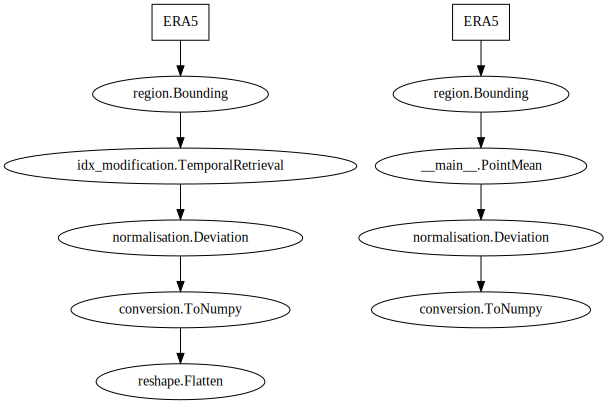

In [4]:
training_pipeline

In [5]:
sample = training_pipeline[doi]

In [6]:
# Show the flattened input shape
sample[0].shape

(24723,)

In [7]:
%%time
# Takes a bit over a minute
training_data = list(training_pipeline)

CPU times: user 1min 10s, sys: 2.44 s, total: 1min 12s
Wall time: 1min 14s


In [8]:
%%time
# Takes about 25 seconds
validation_data = list(validation_pipeline)

CPU times: user 24.1 s, sys: 865 ms, total: 25 s
Wall time: 25.6 s


In [9]:
Xs_train, ys_train = zip(*training_data)
X_train = torch.Tensor(Xs_train)
y_train = torch.Tensor(ys_train).reshape(491).unsqueeze(1)

/jobfs/147536423.gadi-pbs/ipykernel_2479935/1789760784.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_train = torch.Tensor(Xs_train)


In [10]:
Xs_test, ys_test = zip(*validation_data)
X_test = torch.Tensor(Xs_test)
y_test = torch.Tensor(ys_test).reshape(167).unsqueeze(1)

# Neural Network Design

The following example is a fully-connected network with a variety of activation functions. It has not been optimised for the problem at hand. Simple designs are often useful in establishing a benchmark performance for a neural network approach. This network takes a lot of space in GPU memory because of it being fully-connected. A lot of the work in neural network architecture has been to achieve increased accuracy while simulteneously reducing the size of the network in GPU memory (VRAM).

Starting simple like this is a good way to introduce a problem. A good next step would be to replace the model design below with an alternative such as a CNN.


In [11]:
class MyRegressor(torch.nn.Module):
    """
    Create a simple network
    """

    def __init__(self, input_length):
        super(MyRegressor, self).__init__()

        self.input_length = input_length

        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.input_length, self.input_length),
            torch.nn.Sigmoid(),
            torch.nn.Linear(self.input_length, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.Sigmoid(),
            torch.nn.Linear(64, 1)
        )

    def __call__(self, x):
        return self.model(x)

In [12]:
length = sample[0].shape[0]
model = MyRegressor(length)

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())
print(device)

True
cuda:0


In [14]:
model = model.to(device)

In [15]:
# Loss and optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
print(X_train.shape)
print(y_train.shape)

torch.Size([491, 24723])
torch.Size([491, 1])


In [17]:
# Training loop with loss tracking
n_epochs = 80
train_losses = []
val_losses = []
print_per = 10

i = 0
for epoch in range(n_epochs):

    i += 1
    if i % print_per == 0:
        print(f"Commencing epoch {i}")
        
    # Train
    X_train_torch = X_train.to(device)
    y_train_torch = y_train.to(device)
    optimizer.zero_grad()
    output = model(X_train_torch)
    loss = criterion(output, y_train_torch)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validate on latest training
    model.eval()
    X_test_torch = X_test.to(device)
    y_test_torch = y_test.to(device)        
    with torch.no_grad():
        val_output = model(X_test_torch)
        val_loss = criterion(val_output, y_test_torch)
        val_losses.append(val_loss.item())
    model.train()  # back to training mode

Commencing epoch 10
Commencing epoch 20
Commencing epoch 30
Commencing epoch 40
Commencing epoch 50
Commencing epoch 60
Commencing epoch 70
Commencing epoch 80


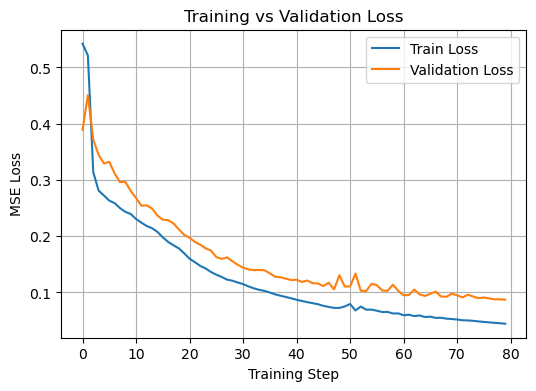

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Training Step')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Commentary on the training

Here we can see overfitting clearly showing itself somewhere between epoch 40 and 60 (it varies quite a bit between runs). The validation loss starts to oscillate significantly. Even though the validation loss appears to continue to trend towards an improvement, this is still a sign that the gains are unlikely to be reliable in practise.

In [19]:
y_pred = model(X_test.to(device)).to('cpu')

In [20]:
# correlation = np.corrcoef(y_test, y_pred)
px.scatter(x=y_test.detach().numpy().reshape(167), y=y_pred.detach().numpy().reshape(167))

In [21]:

model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test.to(device)).to('cpu')
    y_pred = y_pred_tensor.numpy().flatten()


In [22]:
a = y_test.reshape(167)
b = y_pred.reshape(167)

In [23]:


# Quick evaluation of model performance using correlation and RMSE 
correlation = np.corrcoef(a, b)
rmse = scores.continuous.rmse(a, b)

# print(f"Correlation between predicted and actual values: {correlation:.3f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

In [24]:
correlation[0, 1]

np.float64(0.9327869869878489)

In [25]:
rmse

tensor(0.2951)

# Results

These results are similar to, but not better than, the single-variable time-series model that was developed in the previous example. 